# 5. Unpaired Multiomics Integration

Source: https://scib-metrics.readthedocs.io/en/latest/notebooks/lung_example.html


In [ ]:

import warnings
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import scanpy as sc
# import rapids_singlecell as rsc
import anndata

import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score

import scbiot as scb
from scbiot.utils import set_seed

warnings.filterwarnings("ignore")
set_seed(42)

dir = Path(os.environ.get("SCBIOT_TUTORIALS_PATH", Path.cwd()))
print(dir)
print(dir.parent)
verbose = True


## Load
Read the RNA and ATAC inputs from disk.

In [2]:
adata_gex_path = f'{dir}/inputs/Yao-2021-RNA.h5ad'
adata_atac_path = f'{dir}/inputs/Yao-2021-ATAC.h5ad'

adata_gex = sc.read(
    adata_gex_path,
    backup_url="https://figshare.com/ndownloader/files/59742656",
)

adata_atac = sc.read(
    adata_atac_path,
    backup_url="https://figshare.com/ndownloader/files/59742647",
)


## Build reference UMAP if want to map embeddings to reference


## Preprocess
Filter peaks, build gene activity, and align metadata across modalities.

In [4]:

# 0) ATAC preprocessing (peak filtering -> LSI -> GA + smoothing)
# figshare link: https://figshare.com/ndownloader/files/59742641
gtf_file = f"{dir}/inputs/gencode.vM25.chr_patch_hapl_scaff.annotation.gtf.gz"

adata_ga = scb.pp.create_gene_activity(adata_atac, adata_gex, gtf_file=gtf_file, verbose=True)


Removed 19,172 promoter-proximal peaks (2000bp upstream / 500bp downstream). Remaining: 129,642
Running Iterative LSI iteration 1 ...
Running Iterative LSI iteration 2 ...
[GA] Kept 22,358/56,262 genes by biotype ['protein_coding', 'lncRNA']
[GA] Peaks contigs: 21; Genes contigs: 108; Common: 21
[GA] Using gene field: gene_name
[GA] Built GA with shape (54844, 15547) (cells × genes) from 148,814 peaks.
[names] Harmonized symbols; overlaps (case-insensitive): 15,185


In [16]:
import anndata
# adata_gex.write_h5ad('adata_gex.h5ad')
# adata_ga.write_h5ad('adata_ga.h5ad')
# adata_atac.write_h5ad('adata_atac.h5ad')

adata_gex = anndata.read_h5ad('adata_gex.h5ad')
adata_ga = anndata.read_h5ad('adata_ga.h5ad')
adata_atac = anndata.read_h5ad('adata_atac.h5ad')

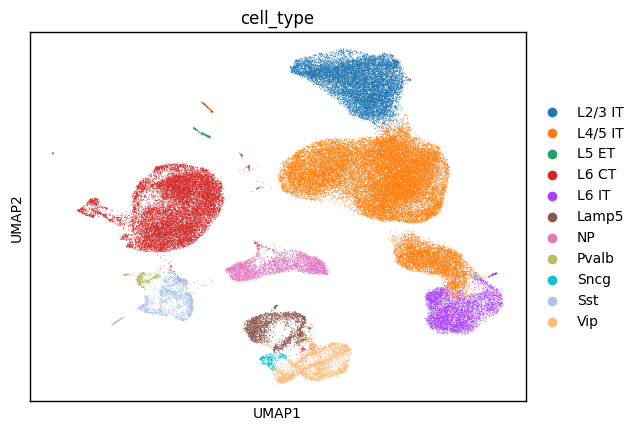

AnnData object with n_obs × n_vars = 69727 × 27123
    obs: 'x', 'cluster_label', 'subclass_label', 'class_label', 'cluster_color', 'size', 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'domain', 'protocol', 'dataset', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts', 'gene_type', 'gene_name', 'mgi_id', 'havana_gene', 'tag', 'n_counts', 'highly_variable', 'highly_variable_

In [17]:
import numpy as np
import scipy.sparse as sp
import scanpy as sc
import anndata
import scbiot as scb

# Strore raw counts
adata_gex.layers["counts"] = adata_gex.X.copy()

adata_ref_umap = adata_gex.copy()

sc.pp.highly_variable_genes(adata_ref_umap, n_top_genes=2000, flavor="seurat_v3")
sc.pp.normalize_total(adata_ref_umap)
sc.pp.log1p(adata_ref_umap)
sc.pp.scale(adata_ref_umap)
sc.tl.pca(adata_ref_umap, n_comps=30, use_highly_variable=True)
sc.pp.neighbors(adata_ref_umap, use_rep="X_pca")
sc.tl.umap(adata_ref_umap)
sc.pl.umap(adata_ref_umap, color='cell_type')
print(adata_ref_umap)
print(adata_ref_umap.uns['umap'])
print(adata_ref_umap.uns['neighbors'])
adata_gex.obsm['X_umap'] = adata_ref_umap.obsm['X_umap']

## Integrate
Co-embed RNA/ATAC, run OT integration, and infer labels with supBIOT.

In [ ]:
adata = scb.pp.autoencoder_map(
    adata_gex, adata_ga,    
    label="modality",    
    keys=("reference", "query"),      
    reference_layer="counts",        
    query_layer='ga_smooth',     
    out_key="X_ae", 
    label_key="cell_type",    
    unlabeled_category="Unknown", 
    n_top_genes=4000,
    n_components=50,
    flag_outlier=True
)

## Integrate disjoint datasets with label transfer (scRNA-seq reference → snATAC-seq gene activity)

For **disjoint** RNA vs GA datasets, use **supervised OT** and run **prealignment** first to reduce global mismatch.

**CORAL prealignment**
```python
prealign="coral"
prealign_strength=0.5
```
**or**

**OT prealignment**
```python
prealign="ot"
prealign_strength=0.8
```

Prealignment runs **before** supervised OT and helps when overlap between datasets is limited.

In [ ]:
adata, metrics = scb.ot.integrate(
    adata,
    obsm_key="X_ae",
    batch_key="modality",  
    prealign='ot',
    prealign_strength=0.8,      
    align_reference=True,    
    label_key="cell_type",    
    unlabeled_category="Unknown",    
    out_key="X_supbiot"    
)


## Prediction of cell types with supBIOT

When a label key is provided, supBIOT outputs two annotation fields:

**pred_cell_type**: the predicted cell type for each cell

**pred_cell_confidence**: the confidence score of the prediction

Cells with pred_cell_confidence < **min_conf** are considered low-confidence and will be assigned NA in pred_cell_type.

In [20]:
import numpy as np

# Initialize UMAP with NaNs
adata.obsm['X_umap'] = np.full((adata.n_obs, 2), np.nan)

# Mask for reference cells
mask = adata.obs['modality'] == 'reference'

# Assign UMAP coordinates
adata.obsm['X_umap'][mask.values, :] = adata_ref_umap.obsm['X_umap']

In [21]:
adata_gex.obs['cell_type'].value_counts()

cell_type
L4/5 IT    29721
L6 CT      13361
L2/3 IT    10915
L6 IT       4514
NP          3147
Vip         2966
Lamp5       2357
Sst         1869
Pvalb        368
Sncg         348
L5 ET        161
Name: count, dtype: int64

In [ ]:
adata = scb.ot.supbiot(
    adata,
    use_rep="X_supbiot",
    label_key="cell_type",
    unlabeled_category="Unknown",
    pred_label_key="pred_cell_type",
    pred_conf_key="pred_confidence",
    use_embedding_ref=True,
    embedding_key="X_umap",
    embedding_k=10,
    embedding_weight_power=2.,       
    min_conf=0.0,
    inplace=True,
)


## Project joint embedding back to reference embedding (optional)

Reference UMAP projection

The preceding `supbiot` call projects query cells into the stored reference UMAP when `use_embedding_ref=True`. For a new joint visualization, compute neighbors and UMAP with Scanpy on `X_supbiot`.

## Evaluate
Inspect predicted labels and confidence distributions for the query cells.

In [23]:
adata_ga = adata[adata.obs['modality'] == 'query'].copy()
adata_gex = adata[adata.obs['modality'] == 'reference'].copy()
adata_ga.obs['pred_cell_type'].value_counts()

pred_cell_type
L4/5 IT    16182
L2/3 IT    15205
L6 CT       8121
L6 IT       3785
Pvalb       2751
Sst         2409
L5 ET       1819
Vip         1599
Lamp5       1428
NP          1340
Sncg         205
Name: count, dtype: int64

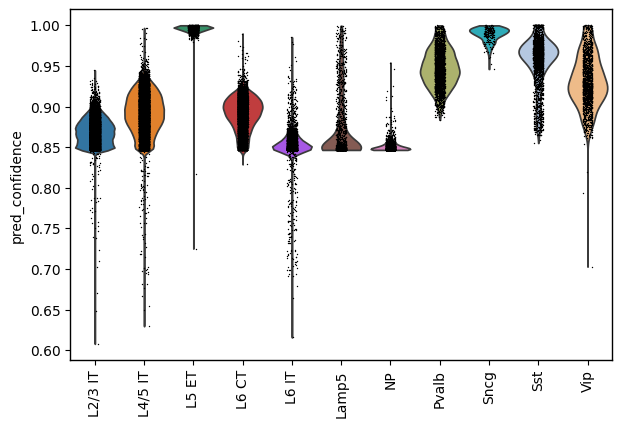

In [24]:
sc.pl.violin(adata_ga, keys="pred_confidence", groupby="pred_cell_type", rotation=90)

## Visualize
Build the UMAP on the supBIOT embedding for modality mixing checks.

In [25]:
# sc.pp.neighbors(adata, use_rep="X_supbiot", n_neighbors=50, metric="cosine")
# sc.tl.umap(adata, min_dist=0.3, spread=1.0, random_state=0)

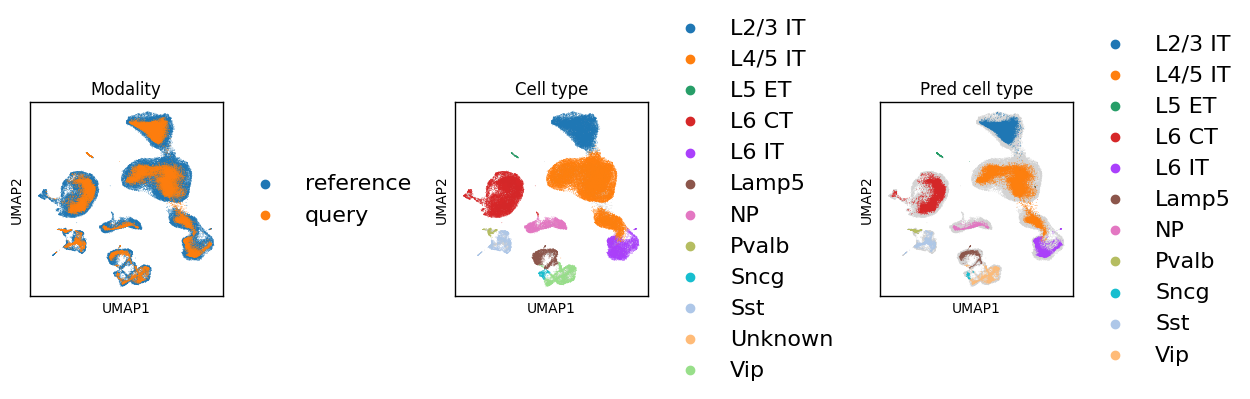

In [26]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scanpy as sc

sc.settings._vector_friendly = True
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1.0

def force_border(ax):
    ax.set_axis_on()
    ax.set_frame_on(True)
    ax.patch.set_visible(True)
    for side in ax.spines.values():
        side.set_visible(True)
        side.set_color("black")
        side.set_linewidth(1.0)

def mask_drop_unknown_na(adata, key, drop=("Unknown", "Unkown", "NA", "NaN", "None", "")):
    s = adata.obs[key].astype("string")
    low = s.str.strip().str.lower()
    drop_low = {d.lower() for d in drop}
    m = s.notna() & (~low.isin(drop_low))
    return m.to_numpy(dtype=bool, na_value=False)

methods = ["X_supbiot"]

m_cell = mask_drop_unknown_na(adata, "cell_type")
m_pred = mask_drop_unknown_na(adata, "pred_cell_type")

ncols = 3 * len(methods)
fig, axes = plt.subplots(1, ncols, figsize=(4.2 * ncols, 4.2), squeeze=False)
axes = axes[0]

for i, method in enumerate(methods):
    axL, axM, axR = axes[3*i], axes[3*i + 1], axes[3*i + 2]

    sc.pl.embedding(
        adata, basis="umap", color="modality",
        frameon=True, ax=axL, show=False,
        legend_loc="right margin", legend_fontsize=16, title="Modality"
    )
    axL.set_box_aspect(1)
    axL.set_xlabel("UMAP1"); axL.set_ylabel("UMAP2")
    force_border(axL)

    xlim, ylim = axL.get_xlim(), axL.get_ylim()

    # hide Unknown/NA cells via mask_obs (no slicing -> no view copy issues)
    sc.pl.embedding(
        adata, basis="umap", color="cell_type",
        mask_obs=m_cell, na_in_legend=False,
        frameon=True, ax=axM, show=False,
        legend_loc="right margin", legend_fontsize=16, title="Cell type"
    )
    axM.set_xlim(xlim); axM.set_ylim(ylim)
    axM.set_box_aspect(1)
    axM.set_xlabel("UMAP1"); axM.set_ylabel("UMAP2")
    force_border(axM)

    sc.pl.embedding(
        adata, basis="umap", color="pred_cell_type",
        mask_obs=m_pred, na_in_legend=False,
        frameon=True, ax=axR, show=False,
        legend_loc="right margin", legend_fontsize=16, title="Pred cell type"
    )
    axR.set_xlim(xlim); axR.set_ylim(ylim)
    axR.set_box_aspect(1)
    axR.set_xlabel("UMAP1"); axR.set_ylabel("UMAP2")
    force_border(axR)

plt.tight_layout()

## Evaluate
Map true labels back to ATAC cells and compute confusion/NMI metrics.

In [27]:
# Map true labels back
adata_ga.obs['cell_type'] = adata_atac.obs['cell_type']

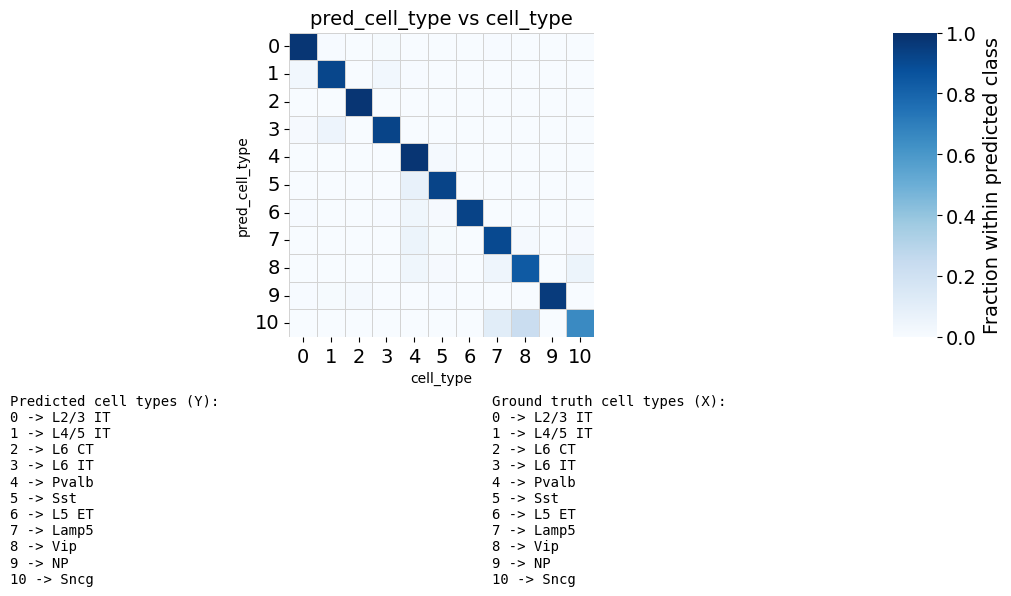

In [28]:
fig, ax, counts_df, norm_df = scb.pl.plot_anndata_confusion(
    adata_ga,
    true_key="cell_type",
    pred_key="pred_cell_type",
    drop_unknown=False,          # key line
    normalize="pred",
    annotate_mapping=True,
    return_data=True,
)

In [29]:
from sklearn.metrics import normalized_mutual_info_score

y_true = adata_ga.obs["cell_type"].astype(str)
y_pred = adata_ga.obs["pred_cell_type"].astype(str)

# keep only valid rows
mask = y_true.notna() & y_pred.notna()

# (optional) ignore "unknown" labels
# mask &= (y_true != "unknown") & (y_pred != "unknown")

nmi = normalized_mutual_info_score(
    y_true[mask].to_numpy(),
    y_pred[mask].to_numpy(),
    average_method="arithmetic",
)

print(f"NMI = {nmi:.6f}")

NMI = 0.861029
